# 삼성전자 2024년 데이터: 첫 구조 확인

한 행은 **한 거래일**입니다. 이번에는 표의 처음과 끝, 크기, 열의 의미와 자료형, 날짜 범위를 확인합니다.

VS Code에서 이 노트북을 열고 오른쪽 위의 **커널 선택**에서 앞선 실습에 사용한 Python 환경을 선택하세요. `samsung-2024.csv`와 이 노트북을 같은 폴더에 두고, 코드 셀을 위에서 아래로 `Shift+Enter`로 실행하세요. 표는 실행한 셀 아래에 나타납니다.

자료 출처와 범위는 [자료안내.md](자료안내.md)를 따릅니다. 네이버 금융에서 수집한 삼성전자(005930)의 저장본이며, 종가는 제공처의 종가 계열입니다. 과거 가격은 제공처의 조정 정책에 따라 달라질 수 있으며, 이번 실습은 저장된 파일 안의 관찰입니다.

## 표 읽기

`pandas`는 표 형태의 데이터를 다루는 도구이며, 코드에서는 `pd`라는 짧은 이름으로 사용합니다. 표는 `df`에 보관하고, `parse_dates`로 `Date` 열을 날짜형으로 읽습니다. 원본 CSV를 수정하거나 저장하는 코드는 없습니다.

In [1]:
import pandas as pd

In [2]:
# Date 열을 날짜형으로 읽고 표를 df에 보관합니다.
df = pd.read_csv("samsung-2024.csv", parse_dates=["Date"])

## 첫 5행

`head(5)`는 CSV에 들어 있는 순서대로 처음 5개 행을 보여 줍니다. 왼쪽의 0, 1, 2 같은 숫자는 행을 구분하는 인덱스이며, CSV의 데이터 열에 포함되지 않습니다.

In [3]:
print("첫 5행")
df.head(5)

첫 5행


,Date,Close,Volume
0,2024-01-02,79600,17142847
1,2024-01-03,77000,21753644
2,2024-01-04,76600,15324439
3,2024-01-05,76600,11304316
4,2024-01-08,76500,11088724


## 마지막 5행

`tail(5)`는 표의 마지막 5개 행을 보여 줍니다.

In [4]:
print("마지막 5행")
df.tail(5)

마지막 5행


,Date,Close,Volume
239,2024-12-23,53500,13672650
240,2024-12-24,54400,11634677
241,2024-12-26,53600,10517075
242,2024-12-27,53700,10747196
243,2024-12-30,53200,12624702


## 전체 행·열 수

`df.shape[0]`은 전체 행 수, `df.shape[1]`은 전체 열 수입니다. 이 자료에서는 행 수가 저장된 거래일 수를 뜻합니다.

In [5]:
print("전체 행·열 수")
pd.DataFrame({
    "전체 행 수": [df.shape[0]],
    "전체 열 수": [df.shape[1]],
})

전체 행·열 수


,전체 행 수,전체 열 수
0,244,3


## 각 열의 의미와 자료형

열의 의미는 자료안내를 따르고, 자료형은 CSV를 읽은 뒤 `df.dtypes`에서 확인합니다. `datetime64[...]`는 날짜·시간 자료형, `int64`는 정수 자료형입니다. 자료형 이름은 실행 환경에 따라 세부 표기가 다를 수 있습니다.

In [6]:
column_info = pd.DataFrame({
    "열 이름": df.columns,
    "의미": ["날짜", "종가(원)", "거래량(주)"],
    "자료형": df.dtypes.astype(str).to_numpy(),
})
print("각 열의 의미와 자료형")
column_info

각 열의 의미와 자료형


,열 이름,의미,자료형
0,Date,날짜,datetime64[us]
1,Close,종가(원),int64
2,Volume,거래량(주),int64


## 가장 이른 날짜와 늦은 날짜

`df["Date"]`는 날짜 열을 선택합니다. 날짜형으로 읽었으므로 `min()`과 `max()`로 전체 표의 가장 이른 날짜와 늦은 날짜를 구할 수 있습니다. 첫 행과 마지막 행이 날짜순이라고 가정하지 않고 실제 값을 확인합니다.

In [7]:
print("날짜 범위")
pd.DataFrame({
    "가장 이른 날짜": [df["Date"].min()],
    "가장 늦은 날짜": [df["Date"].max()],
})

날짜 범위


,가장 이른 날짜,가장 늦은 날짜
0,2024-01-02,2024-12-30


## 열별 빈값과 해당 행 점검

`isna()`로 pandas가 빈값으로 인식한 값(`NaN`, `NaT` 등)을 확인합니다. 열별 빈값 수와 빈값이 하나라도 있는 행을 원래 인덱스와 함께 보여 줍니다. 빈값이 없으면 없다고 출력합니다.

**빈값이 0개여도 모든 거래일이 들어 있다는 뜻은 아닙니다.** 어떤 거래일의 행 전체가 빠졌다면 이 점검으로는 알 수 없습니다. 거래일 누락 여부는 해당 기간의 거래소 거래일 달력과 별도로 대조해야 합니다.

아래 코드는 원본 `df`와 CSV를 바꾸지 않으며, 빈값을 채우거나 행을 삭제하지 않습니다.

In [8]:
# 점검을 다시 시작하면 이전 실행의 분석용 값을 먼저 비웁니다.
checks_ok = False
df_sorted = None

from IPython.display import display

missing_counts = df.isna().sum()
missing_row_mask = df.isna().any(axis=1)

print("열별 빈값 수")
display(missing_counts.rename("빈값 수").to_frame())

if missing_row_mask.any():
    print(f"빈값이 있는 행: {int(missing_row_mask.sum())}개")
    display(df.loc[missing_row_mask])
else:
    print("빈값이 있는 행: 없음")

열별 빈값 수


,빈값 수
Date,0
Close,0
Volume,0


빈값이 있는 행: 없음


## 중복 날짜 수와 해당 행 점검

중복 날짜 수는 **같은 날짜의 첫 행을 제외하고 추가로 나타난 행 수**로 셉니다. 예를 들어 한 날짜가 3번 나오면 중복은 2개입니다. 중복된 서로 다른 날짜 수도 함께 출력하고, 문제 행 표에는 첫 행을 포함해 해당 날짜의 모든 행을 보여 줍니다. 날짜 빈값은 위 빈값 점검에서 다루므로 중복 날짜 집계에서는 제외합니다.

In [9]:
# 점검을 다시 시작하면 이전 실행의 분석용 값을 먼저 비웁니다.
checks_ok = False
df_sorted = None

date_present_mask = df["Date"].notna()
duplicate_date_count = int(
    (date_present_mask & df["Date"].duplicated(keep="first")).sum()
)
duplicate_date_mask = date_present_mask & df["Date"].duplicated(keep=False)

print(f"중복 날짜 수 (첫 행 제외): {duplicate_date_count}개")
print(f"중복된 서로 다른 날짜 수: {df.loc[duplicate_date_mask, 'Date'].nunique()}개")

if duplicate_date_mask.any():
    print("중복 날짜에 해당하는 모든 행 (원래 순서와 인덱스)")
    display(df.loc[duplicate_date_mask])
else:
    print("중복 날짜에 해당하는 행: 없음")

중복 날짜 수 (첫 행 제외): 0개
중복된 서로 다른 날짜 수: 0개
중복 날짜에 해당하는 행: 없음


## 날짜 오름차순 여부와 순서 문제 행 점검

현재 `df`의 행 순서에서 날짜가 오름차순인지 확인합니다. 같은 날짜가 이어져도 `is_monotonic_increasing`은 참일 수 있으므로 중복 여부는 별도로 점검합니다.

문제 행 표에는 날짜가 직전 날짜보다 이른 행과 비교 대상 날짜를 함께 표시합니다. 날짜 빈값이 있으면, 날짜가 있는 행끼리 원래 순서로 비교하되 전체 날짜 순서는 정상으로 판정하지 않습니다. 점검용으로 행을 선택할 뿐 원본에서 행을 삭제하지 않습니다.

In [10]:
# 점검을 다시 시작하면 이전 실행의 분석용 값을 먼저 비웁니다.
checks_ok = False
df_sorted = None

date_present_mask = df["Date"].notna()
date_order_ok = df["Date"].is_monotonic_increasing
print(f"날짜가 오름차순인가요? {date_order_ok}")

# 날짜가 있는 행을 원래 순서대로 비교합니다. 원본 df는 바꾸지 않습니다.
dated_rows = df.loc[date_present_mask]
previous_date = dated_rows["Date"].shift(1)
order_problem_mask = dated_rows["Date"].lt(previous_date)

if order_problem_mask.any():
    print("직전 유효 날짜보다 날짜가 이른 행")
    display(dated_rows.loc[order_problem_mask].assign(
        직전_유효_날짜=previous_date.loc[order_problem_mask]
    ))
else:
    print("직전 유효 날짜보다 날짜가 이른 행: 없음")

if not date_present_mask.all():
    print("날짜 빈값이 있어 전체 날짜 순서를 정상으로 판정할 수 없습니다.")
    print("날짜가 비어 있는 행")
    display(df.loc[~date_present_mask])
elif date_order_ok:
    print("날짜 순서 문제: 없음")

날짜가 오름차순인가요? True
직전 유효 날짜보다 날짜가 이른 행: 없음
날짜 순서 문제: 없음


## 점검 통과 시 날짜순 분석용 복사본 만들기

표가 비어 있지 않고, 빈값이 없고, 중복 날짜가 없고, 날짜가 오름차순일 때만 `df_sorted`를 만듭니다. 문제가 있으면 자동으로 보정하지 않고 안내만 출력합니다. `sort_values()`와 `copy()`로 별도 표를 만들며 원본 `df`의 값·행 순서·인덱스와 CSV는 그대로 유지합니다.

각 점검 코드 셀은 시작할 때 `checks_ok = False`, `df_sorted = None`으로 분석 상태를 초기화합니다. 아래 셀은 현재 `df`를 다시 점검하고 복사본 생성까지 마쳐야 `checks_ok = True`로 바꿉니다. 따라서 점검 도중 오류가 나거나 점검을 통과하지 못하면 이전 실행의 `df_sorted`로 분석을 이어 갈 수 없습니다. 점검 셀을 다시 실행한 뒤에는 이 복사본 생성 셀까지 실행해야 그래프를 그릴 수 있습니다.

In [11]:
# 점검을 다시 시작하면 이전 실행의 분석용 값을 먼저 비웁니다.
checks_ok = False
df_sorted = None

# 앞선 셀에 남아 있는 결과에 의존하지 않고 현재 df를 다시 점검합니다.
missing_row_mask = df.isna().any(axis=1)
date_present_mask = df["Date"].notna()
duplicate_date_count = int(
    (date_present_mask & df["Date"].duplicated(keep="first")).sum()
)
date_order_ok = df["Date"].is_monotonic_increasing

if (
    not df.empty
    and not missing_row_mask.any()
    and duplicate_date_count == 0
    and date_order_ok
):
    df_sorted = df.sort_values("Date", ascending=True, kind="stable").copy()
    checks_ok = True  # 복사본 생성까지 끝나야 통과 상태로 바꿉니다.
    print("점검 결과: 빈값·중복 날짜·날짜 순서 문제 없음")
    print(f"날짜순 분석용 복사본 df_sorted를 만들었습니다. ({len(df_sorted)}행)")
else:
    print("점검 결과: 빈 표이거나 문제가 있습니다. 위의 문제 행을 확인하세요.")
    print("df_sorted를 비웠습니다. 자료를 확인한 뒤 점검 셀을 다시 실행하세요.")

점검 결과: 빈값·중복 날짜·날짜 순서 문제 없음
날짜순 분석용 복사본 df_sorted를 만들었습니다. (244행)


## 날짜별 종가와 최고·최저 종가의 원래 행

점검을 통과한 `df_sorted`로 날짜별 종가를 선 그래프로 그립니다. 최고·최저 종가와 같은 값을 갖는 **모든 날짜**를 찾아 표시하며, 같은 가격의 날짜들은 하나의 주석에 묶어 글자가 겹치지 않도록 합니다. 최고와 최저가 같으면 두 표시를 하나로 합칩니다.

한글 폰트는 `Noto Sans CJK KR`를 우선 사용하고, 없으면 설치된 다른 한글 폰트 후보, 마지막으로 `DejaVu Sans`를 사용합니다. 한글 폰트가 없는 환경에서는 대체 폰트의 한글 표시가 제한될 수 있습니다. 그림은 11×4.5인치이며 축·눈금·주석은 13포인트, 제목은 16포인트입니다.

그래프 아래에는 최고·최저 종가에 해당하는 행을 원래 인덱스와 모든 열을 유지해 보여 줍니다. 계산 중간값은 함수 안에서만 사용합니다. 점검을 통과하지 않았거나 점검 후 `df`가 달라졌으면 그래프와 표를 만들지 않습니다.

그래프 폰트: Noto Sans CJK KR


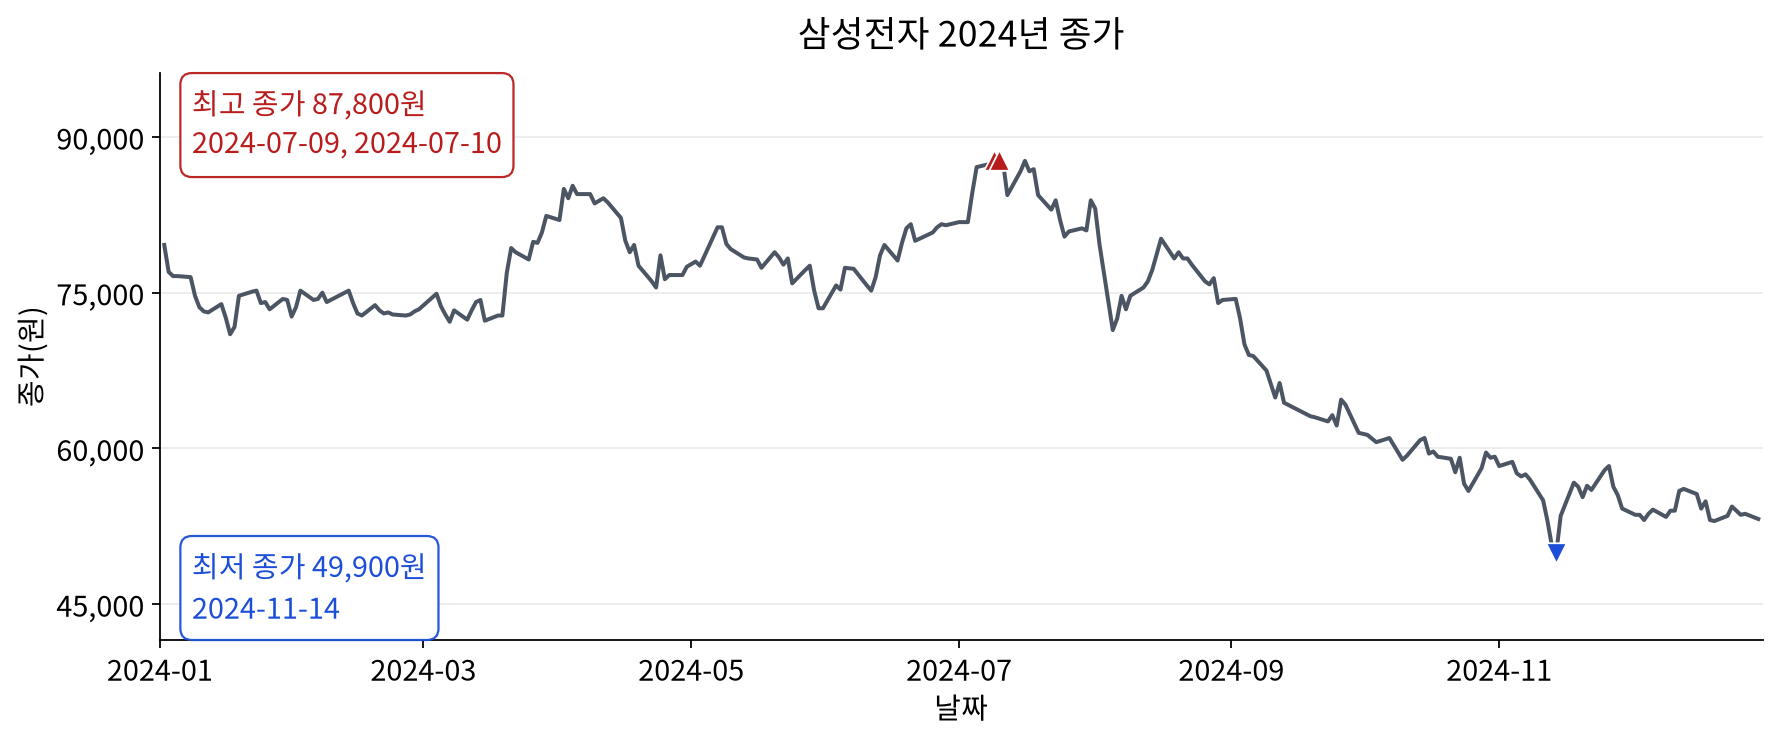

최고 종가: 87,800원 — 해당하는 원래 행 모두 (2행)


,Date,Close,Volume
127,2024-07-09,87800,21336201
128,2024-07-10,87800,17813847


최저 종가: 49,900원 — 해당하는 원래 행 모두 (1행)


,Date,Close,Volume
212,2024-11-14,49900,48510715


In [12]:
# 점검 통과 상태와 분석용 복사본을 확인한 뒤에만 그립니다.
if not globals().get("checks_ok", False) or globals().get("df_sorted") is None:
    print("그래프를 그리려면 위의 점검 셀과 df_sorted 생성 셀을 먼저 실행하세요.")
elif globals().get("df") is None or not df_sorted.equals(df):
    checks_ok = False
    df_sorted = None
    print("점검 후 df가 달라졌습니다. 점검 셀과 df_sorted 생성 셀을 다시 실행하세요.")
else:
    import textwrap
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib import font_manager
    from matplotlib.ticker import StrMethodFormatter, MaxNLocator
    from IPython.display import display

    def show_close_analysis(data):
        # 첫 날짜 하나만 고르지 않고 같은 최고·최저 가격의 행을 모두 선택합니다.
        max_close = data["Close"].max()
        min_close = data["Close"].min()
        max_rows = data.loc[data["Close"].eq(max_close)].copy()
        min_rows = data.loc[data["Close"].eq(min_close)].copy()

        available_fonts = {font.name for font in font_manager.fontManager.ttflist}
        font_candidates = [
            "Noto Sans CJK KR", "Noto Sans KR", "NanumGothic",
            "Malgun Gothic", "AppleGothic", "NanumBarunGothic",
            "Noto Serif CJK KR", "Noto Sans CJK JP", "Noto Sans CJK SC",
            "Arial Unicode MS",
        ]
        selected_font = next(
            (name for name in font_candidates if name in available_fonts),
            "DejaVu Sans",
        )
        print(f"그래프 폰트: {selected_font}")

        # 설정은 이 그림에만 적용합니다.
        with plt.rc_context({
            "font.family": [selected_font, "DejaVu Sans"],
            "font.size": 13,
            "axes.titlesize": 16,
            "axes.labelsize": 13,
            "xtick.labelsize": 13,
            "ytick.labelsize": 13,
            "legend.fontsize": 13,
            "axes.unicode_minus": False,
        }):
            fig, ax = plt.subplots(figsize=(11, 4.5), dpi=160, layout="constrained")
            ax.plot(data["Date"], data["Close"], color="#4b5563", linewidth=1.8)

            # 주석을 위·아래로 나누고 같은 가격의 날짜는 한 상자에 모읍니다.
            # 모든 해당 지점은 삼각형으로 표시합니다.
            groups = [
                ("최고", max_rows, "#b91c1c", "^", (0.02, 0.98), "top"),
                ("최저", min_rows, "#1d4ed8", "v", (0.02, 0.02), "bottom"),
            ]
            if max_close == min_close:
                groups = [
                    ("최고·최저", max_rows, "#6d28d9", "D", (0.02, 0.98), "top")
                ]

            for label, rows, color, marker, position, vertical in groups:
                ax.scatter(
                    rows["Date"], rows["Close"], color=color, marker=marker,
                    s=85, edgecolors="white", linewidths=0.8, zorder=3,
                )
                dates_text = textwrap.fill(
                    ", ".join(rows["Date"].dt.strftime("%Y-%m-%d")),
                    width=32, break_long_words=False, break_on_hyphens=False,
                )
                annotation = f"{label} 종가 {rows['Close'].iloc[0]:,.0f}원\n{dates_text}"
                ax.text(
                    *position, annotation, transform=ax.transAxes,
                    ha="left", va=vertical, fontsize=13, color=color,
                    linespacing=1.4,
                    bbox={"boxstyle": "round,pad=0.4", "facecolor": "white",
                          "edgecolor": color, "alpha": 0.95},
                    zorder=4,
                )

            ax.set_title("삼성전자 2024년 종가", pad=12)
            ax.set_xlabel("날짜")
            ax.set_ylabel("종가(원)")
            ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
            ax.margins(x=0.03, y=0.22)
            ax.set_xlim(
                data["Date"].min() - pd.Timedelta(days=1),
                data["Date"].max() + pd.Timedelta(days=1),
            )
            ax.grid(axis="y", alpha=0.25)
            ax.spines[["top", "right"]].set_visible(False)
            plt.show()

        # 모든 열과 원래 인덱스를 유지하며, 동률인 행도 생략하지 않습니다.
        with pd.option_context("display.max_rows", None, "display.max_columns", None):
            print(f"최고 종가: {max_close:,.0f}원 — 해당하는 원래 행 모두 ({len(max_rows)}행)")
            display(max_rows)
            print(f"최저 종가: {min_close:,.0f}원 — 해당하는 원래 행 모두 ({len(min_rows)}행)")
            display(min_rows)

    show_close_analysis(df_sorted)

**관찰 질문:** 그래프에 나타난 2024년 기간 안에서 종가가 상대적으로 높은 구간과 낮은 구간은 각각 언제이며, 날짜와 가격을 근거로 어떻게 설명할 수 있나요?

## 날짜별 거래량과 상위 5일

앞서 점검한 `df_sorted`로 날짜별 거래량을 막대 그래프로 확인합니다. 세로축은 **거래량(백만 주)**이며, 1백만 주는 1,000,000주입니다. 그림은 11×4.5인치, 글자는 13포인트 이상으로 유지합니다. 표에는 거래량을 **주**, 종가를 **원** 단위로 표시합니다.

- **평균**은 거래량의 합계를 자료에 있는 날짜 수(거래일 수)로 나눈 값입니다. 그래프에는 긴 점선으로 표시합니다.
- **중앙값**은 거래량을 크기순으로 놓았을 때 가운데 값입니다. 개수가 짝수이면 가운데 두 값의 평균입니다. 그래프에는 짧은 점선으로 표시합니다.
- **최댓값**은 하루 거래량 중 가장 큰 값입니다.

아래 표에서 평균·중앙값·최댓값과 거래량이 큰 상위 5일의 날짜·종가·거래량을 확인합니다. 거래량이 같으면 날짜가 이른 순서로 5일을 고릅니다. 거래량은 거래된 주식 수이며, **거래량만으로 매수세가 강했다거나 가격이 오른 원인을 단정할 수는 없습니다.**

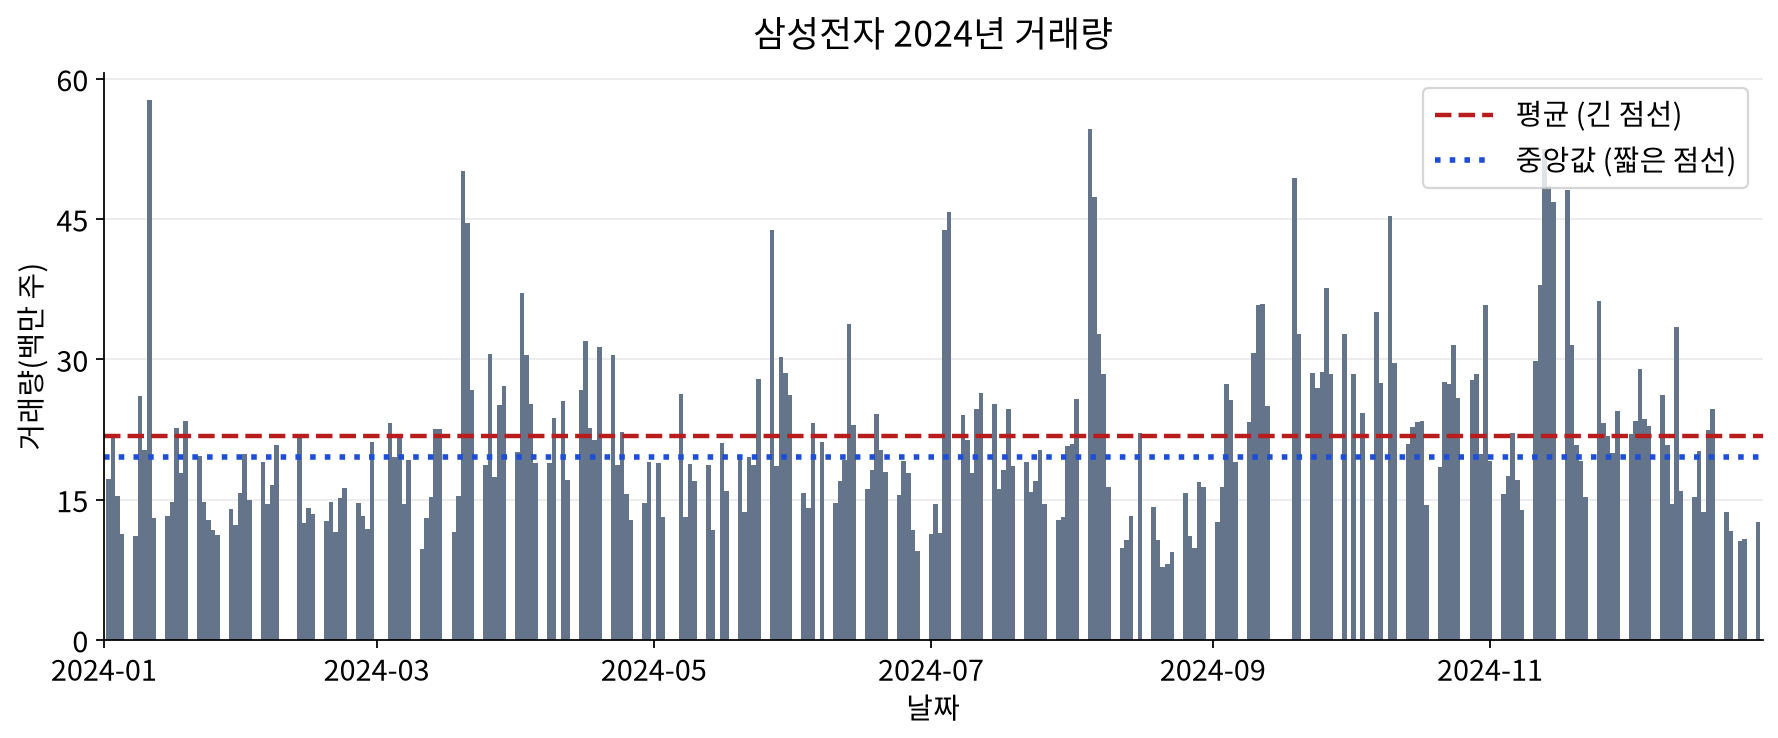

거래량 요약 — 단위: 주


평균(주),중앙값(주),최댓값(주)
"21,738,603.4","19,597,440.5","57,691,266"


거래량 상위 5일 — 종가: 원, 거래량: 주


날짜,종가(원),거래량(주)
2024-01-11,"73,200","57,691,266"
2024-08-05,"71,400","54,608,790"
2024-11-13,"50,600","52,527,995"
2024-03-20,"76,900","50,106,297"
2024-09-19,"63,100","49,402,713"


In [13]:
# 앞선 점검 결과가 현재 자료에도 유효한지 확인합니다.
if not globals().get("checks_ok", False) or globals().get("df_sorted") is None:
    print("위의 점검 셀과 df_sorted 생성 셀을 먼저 실행하세요.")
elif globals().get("df") is None or not df_sorted.equals(df):
    checks_ok = False
    df_sorted = None
    print("점검 후 df가 달라졌습니다. 점검 셀과 df_sorted 생성 셀을 다시 실행하세요.")
else:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from matplotlib import font_manager
    from matplotlib.ticker import StrMethodFormatter, MaxNLocator
    from IPython.display import display

    def show_volume_analysis(data):
        volume = data["Volume"]  # 원자료 단위: 주
        mean_volume = volume.sum() / len(data)
        median_volume = volume.median()
        max_volume = volume.max()

        available_fonts = {font.name for font in font_manager.fontManager.ttflist}
        font_candidates = [
            "Noto Sans CJK KR", "Noto Sans KR", "NanumGothic",
            "Malgun Gothic", "AppleGothic", "NanumBarunGothic",
            "Noto Serif CJK KR", "Noto Sans CJK JP", "Noto Sans CJK SC",
            "Arial Unicode MS",
        ]
        selected_font = next(
            (name for name in font_candidates if name in available_fonts),
            "DejaVu Sans",
        )
        with plt.rc_context({
            "font.family": [selected_font, "DejaVu Sans"],
            "font.size": 13, "axes.titlesize": 16, "axes.labelsize": 13,
            "xtick.labelsize": 13, "ytick.labelsize": 13,
            "legend.fontsize": 13, "axes.unicode_minus": False,
        }):
            fig, ax = plt.subplots(figsize=(11, 4.5), dpi=160, layout="constrained")
            # 막대와 두 기준선을 모두 백만 주 단위로 맞춥니다.
            ax.bar(data["Date"], volume / 1_000_000, width=1, color="#64748b")
            ax.axhline(
                mean_volume / 1_000_000, color="#b91c1c", linestyle="--",
                linewidth=2, label="평균 (긴 점선)",
            )
            ax.axhline(
                median_volume / 1_000_000, color="#1d4ed8", linestyle=":",
                linewidth=2.5, label="중앙값 (짧은 점선)",
            )
            ax.set_title("삼성전자 2024년 거래량", pad=12)
            ax.set_xlabel("날짜")
            ax.set_ylabel("거래량(백만 주)")
            ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9, 11]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
            ax.set_ylim(bottom=0)
            ax.margins(x=0.02)
            ax.set_axisbelow(True)
            ax.set_xlim(
                data["Date"].min() - pd.Timedelta(days=1),
                data["Date"].max() + pd.Timedelta(days=1),
            )
            ax.grid(axis="y", alpha=0.25)
            ax.spines[["top", "right"]].set_visible(False)
            ax.legend(loc="upper right")
            plt.show()

        print("거래량 요약 — 단위: 주")
        summary = pd.DataFrame({
            "평균(주)": [mean_volume],
            "중앙값(주)": [median_volume],
            "최댓값(주)": [max_volume],
        })
        display(summary.style.hide(axis="index").format({
            "평균(주)": "{:,.1f}", "중앙값(주)": "{:,.1f}", "최댓값(주)": "{:,.0f}",
        }))

        print("거래량 상위 5일 — 종가: 원, 거래량: 주")
        top_days = data.nlargest(5, "Volume", keep="first")[["Date", "Close", "Volume"]]
        top_days = top_days.rename(columns={"Date": "날짜", "Close": "종가(원)", "Volume": "거래량(주)"})
        display(top_days.style.hide(axis="index").format({
            "날짜": "{:%Y-%m-%d}", "종가(원)": "{:,.0f}", "거래량(주)": "{:,.0f}",
        }))

    show_volume_analysis(df_sorted)

## CSV와 대조한 관찰기록

### 이번에 확인한 사실

대상은 `samsung-2024.csv`에 저장된 **삼성전자(005930) 한 종목의 2024-01-02~2024-12-30, 244행**이다. 한 행은 한 거래일이며, `Date`는 날짜, `Close`는 종가(원), `Volume`은 하루 거래량(주)이다. 단위와 출처는 [자료안내.md](자료안내.md)를 따랐다. 빈값과 중복 날짜는 없고 날짜는 오름차순이다. 이 점검만으로 빠진 거래일이 없다고 단정하지는 않는다.

1. **관찰 ①은 최고 종가의 동률 날짜를 보완한다.** 종가 최댓값은 **2024-07-09와 2024-07-10의 87,800원**, 최솟값은 **2024-11-14의 49,900원**이다. 7월 9일의 날짜·가격과 11월 14일의 날짜·가격은 맞지만, 최고 종가가 7월 9일에만 있었다고 읽히지 않도록 7월 10일도 적는다.
2. **관찰 ②는 만 주 단위로 반올림한 근삿값과 일치한다.** 저장된 244거래일의 하루 거래량 평균은 **21,738,603.381…주(약 2,174만 주)**, 중앙값은 **19,597,440.5주(약 1,960만 주)**이다. 평균은 거래량 합계 5,304,219,225주를 244로 나눈 값이다. 중앙값은 정렬한 244개 값 중 가운데 두 값의 평균이므로 소수점이 생긴다. 달력의 모든 날을 분모로 삼거나 월별 통계를 평균 낸 값이 아니다.

최고·최저 종가의 근거 행은 다음과 같다. 아래 표의 인덱스는 CSV를 읽을 때 부여된 0부터 시작하는 원래 행 인덱스이며, CSV의 열이나 파일 줄 번호는 아니다.

| 원래 인덱스 | Date | Close (원) | Volume (주) | 확인 내용 |
| ---: | --- | ---: | ---: | --- |
| 127 | 2024-07-09 | 87,800 | 21,336,201 | 최고 종가 |
| 128 | 2024-07-10 | 87,800 | 17,813,847 | 최고 종가, 동률 |
| 212 | 2024-11-14 | 49,900 | 48,510,715 | 최저 종가 |

**다음 질문의 첫 확인: 거래량 최대일과 바로 전후 거래일.** 거래량 최댓값은 **2024-01-11의 57,691,266주**이며 해당 날짜는 하나다. 원래 CSV의 모든 열을 유지해 그 행과 앞뒤 한 거래일을 확인했다. 전후는 달력상 하루가 아니라 CSV에서 날짜순으로 이웃한 거래일을 뜻한다.

| 원래 인덱스 | Date | Close (원) | Volume (주) | 위치 |
| ---: | --- | ---: | ---: | --- |
| 6 | 2024-01-10 | 73,600 | 20,259,529 | 직전 거래일 |
| 7 | 2024-01-11 | 73,200 | 57,691,266 | 거래량 최대일 |
| 8 | 2024-01-12 | 73,100 | 13,038,939 | 다음 거래일 |

이 세 행에서는 종가가 **73,600원 → 73,200원 → 73,100원**으로 각각 400원, 100원 낮아졌다. 거래량은 1월 11일에 증가하고 다음 거래일에 줄었다. 평균 거래량이 중앙값보다 크며, 거래량이 가장 많았던 날의 종가는 직전 거래일보다 낮았다. 이는 표에서 읽은 관찰이며, 거래량이 가격 하락을 일으켰다는 뜻은 아니다.

그래프의 가로축은 두 그림 모두 `Date` 최솟값의 하루 전부터 최댓값의 하루 뒤까지인 **2024-01-01~2024-12-31**이다. 양끝 하루는 표시 여백이며 관측치를 추가한 것이 아니다. 2025년 1월 눈금은 표시 범위 밖이다. 종가 그래프의 세로축은 원, 거래량 그래프는 백만 주(1백만 주 = 1,000,000주), 위 표와 통계의 거래량 단위는 주다.

### 아직 답하지 않은 질문

처음의 다음 질문은 “거래량이 가장 많았던 날의 실제 행과 그 전후 가격도 함께 보면 어떤 움직임이 보일까?”였다. 위에서는 바로 전후 한 거래일까지만 확인했다. **앞뒤 다섯 거래일로 범위를 넓혀도 종가가 계속 낮아지는가, 중간에 방향이 바뀌는가?** 이 범위는 아직 비교하지 않았다.

또한 **1~6월과 7~12월로 나누면 종가 범위와 거래량 평균·중앙값의 관찰이 어떻게 달라지는가?** [추가 실습 노트북](first-eda-extra.ipynb)에 비교 코드를 준비했으며, 추가 셀을 직접 실행해 두 기간의 요약값을 비교할 수 있다.

### 관찰의 한계

이번 결과는 **한 종목·한 기간의 저장된 CSV 안에서 확인한 사실**이다. 제공처의 종가 계열이며 공식 가격 원본과 별도로 대조하지 않았다. 다른 종목이나 기간으로 일반화할 수 없고, 가격·거래량 움직임의 원인을 밝히거나 미래를 예측한 결과도 아니다. 수익률·원인·예측 계산은 하지 않았다. 검증에는 이 폴더의 `.venv/bin/python`을 사용했으며 원본 CSV는 보존했다.
